Loading GridInfo_FF.mat...
Grid dimensions: (241, 121) | Total points: 29161


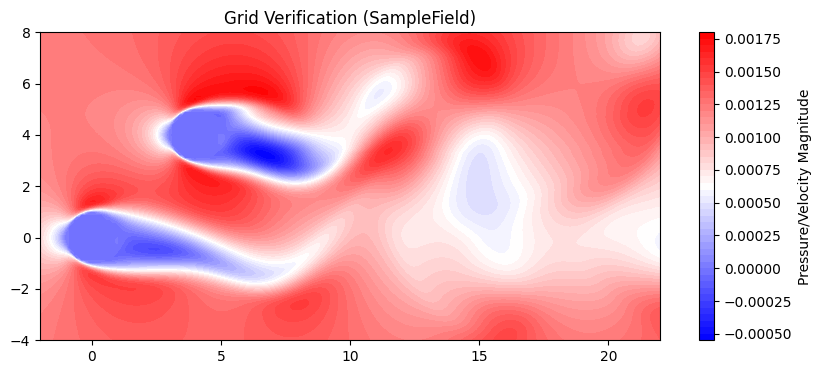

Reading snapshots_ux_mapped.mat...
Reading snapshots_uy_mapped.mat...
Reading snapshotsFF_ux_mapped.mat...
Reading snapshotsFF_uy_mapped.mat...
Alignment verified: Snapshot columns match grid points.


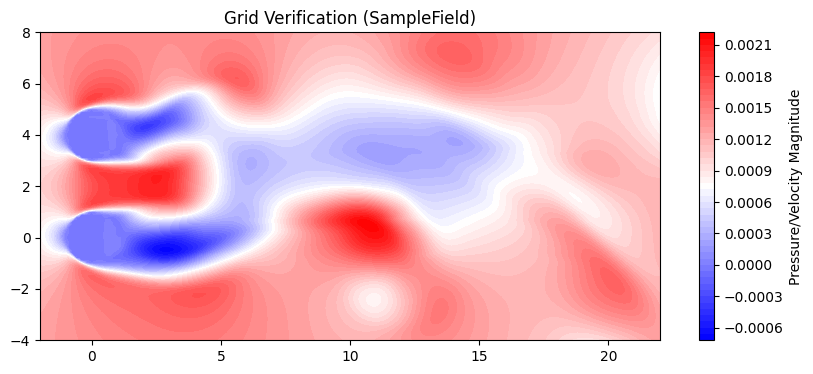


--- Data Split Summary ---
Total Snapshots: 21842
Run 1: Train=5606, Test=565
Run 2: Train=14236, Test=1435
Processing Complete. Ready for POD with 29161 aligned points.


In [2]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import platform

# --- 1. Configuration & Paths ---
load_dotenv()
current_os = platform.system()
base_dir = os.getenv("BASE_DIR_WIN") if current_os == "Windows" else os.getenv("BASE_DIR_LIN")

input_dir = os.path.join(base_dir, "data/kevin_2cylinder/LD0_TD2")
output_dir = os.path.join(base_dir, "output/kevin_2cylinder")
os.makedirs(output_dir, exist_ok=True)

def load_v73(filename):
    path = os.path.join(input_dir, filename)
    print(f"Reading {filename}...")
    with h5py.File(path, 'r') as f:
        # Sniff for the correct data key (snapsx, snapsy, etc.)
        valid_keys = [k for k in f.keys() if k not in ['#refs#', '#subsystem#']]
        data = f[valid_keys[0]][:]
    return data

# --- 2. Load Grid & Validate Alignment ---
print("Loading GridInfo_FF.mat...")
with h5py.File(os.path.join(input_dir, "GridInfo_FF.mat"), 'r') as f:
    Xi = np.array(f['XI'])
    Yi = np.array(f['YI'])
    SampleField = np.array(f['SampleField'])

# Flattening the grid to match the snapshot point-cloud format
x_flat = Xi.ravel()
y_flat = Yi.ravel()

print(f"Grid dimensions: {Xi.shape} | Total points: {x_flat.size}")

# Validation Plot: Confirming coordinate alignment
plt.figure(figsize=(10, 4))
plt.contourf(Xi, Yi, np.reshape(SampleField, Xi.shape), levels=50, cmap='bwr')
plt.title("Grid Verification (SampleField)")
plt.colorbar(label='Pressure/Velocity Magnitude')
plt.show()

# --- 3. Load Velocity Runs ---
ux1 = load_v73("snapshots_ux_mapped.mat")
uy1 = load_v73("snapshots_uy_mapped.mat")
ux2 = load_v73("snapshotsFF_ux_mapped.mat")
uy2 = load_v73("snapshotsFF_uy_mapped.mat")

# --- 4. Dimension Guard ---
if ux1.shape[1] != x_flat.size:
    print(f"!!! ERROR: Data points ({ux1.shape[1]}) != Grid points ({x_flat.size})")
    # If there is still a mismatch, we likely need to check if Xi/Yi are transposed
    # compared to the vectorization used by your colleague.
else:
    print("Alignment verified: Snapshot columns match grid points.")


# Validation Plot: Confirming coordinate alignment
plt.figure(figsize=(10, 4))
plt.contourf(Xi, Yi, np.reshape(ux1[0,:], Xi.shape), levels=50, cmap='bwr')
plt.title("Grid Verification (SampleField)")
plt.colorbar(label='Pressure/Velocity Magnitude')
plt.show()

# --- 5. Proportional Split Logic ---
n1, n2 = ux1.shape[0], ux2.shape[0]
n_total = n1 + n2
n_test_target = 2000
n1_test = int((n1 / n_total) * n_test_target)
n2_test = n_test_target - n1_test 

print(f"\n--- Data Split Summary ---")
print(f"Total Snapshots: {n_total}")
print(f"Run 1: Train={n1-n1_test}, Test={n1_test}")
print(f"Run 2: Train={n2-n2_test}, Test={n2_test}")

ux_train = np.vstack([ux1[:-n1_test], ux2[:-n2_test]])
uy_train = np.vstack([uy1[:-n1_test], uy2[:-n2_test]])
ux_test = np.vstack([ux1[-n1_test:], ux2[-n2_test:]])
uy_test = np.vstack([uy1[-n1_test:], uy2[-n2_test:]])

# --- 6. Save Unified HDF5 ---
h5_path = os.path.join(output_dir, "flipflop_velocity_unified.h5")
with h5py.File(h5_path, 'w') as f:
    f.create_dataset('x', data=x_flat)
    f.create_dataset('y', data=y_flat)
    # Store grid shape for easy reshaping later
    f.create_dataset('grid_shape', data=np.array(Xi.shape))
    
    tr = f.create_group('train')
    tr.create_dataset('ux', data=ux_train.astype(np.float32))
    tr.create_dataset('uy', data=uy_train.astype(np.float32))
    
    ts = f.create_group('test')
    ts.create_dataset('ux', data=ux_test.astype(np.float32))
    ts.create_dataset('uy', data=uy_test.astype(np.float32))

print(f"Processing Complete. Ready for POD with {x_flat.size} aligned points.")